pag195 - 226

# Probabilities of Default: Continuous-Time Hazard Models

We will start out notebook by loading all datasets that might be useful for us.

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
import statsmodels.api as sm
from scipy import stats
from scipy.stats import lognorm
from sklearn.metrics import roc_auc_score
from statsmodels.miscmodels.ordinal_model import OrderedModel
from optbinning import OptimalBinning
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
warnings.simplefilter(action='ignore', category=FutureWarning)
from lifelines import KaplanMeierFitter
from lifelines.utils import survival_table_from_events
from lifelines import NelsonAalenFitter
from lifelines.statistics import multivariate_logrank_test
from lifelines import CoxPHFitter

In [80]:
csvs_path = [rf'datasets/{name}.csv' for name in ['hmeq', 'lgd', 'ratings', 'mortgage']]
hmeq, lgd, ratings, mortgage = list(map(pd.read_csv, csvs_path))

### Introduction

Continuos-time hazar models in a credit risk context describe the survival time of a borrower or loan $T_i (T_i >= 0)$, which is known as time to default, as a random variable in continuous forme. It's generally measured from loan origination.


### Censoring

Censoring is an important characteristic of survival analysis data. It occurs when we have some information about the survival time, but we don't know the exact survival time. There are three types of censoring: right-censoring, left-censoring and interval-censoring.

An observation on an variable T is right-censored if all that you know about T is that is greater than some value. For example, you are tracking how long a laptop battery lasts. After 10 hours, the study ends, but the battery is still working. You know its life is >10 hours, but not exactly how long. The same applies to companies, suppose you are tracking a company up to the age of 50 but you do not know when it will default as you can no longer observe the company, you only know it will be after the age of 50, and so, it's right-censored at age 50.

An observation on a variable T is left-censored if all you know about T is that it is smaller than some value. For example, suppose you are tracking at which age childern learn to ride a bike. A child enters your data at age 5 already knowing how to ride. You know the event happened before age 5 but not the specific date.

An observation on a variable T is interval-censored if all that you know about T is that it is bigger than some value and smaller than some value. In other words, the time of the event is situated in a countinuous internal.

Basically the problem of censoring is that data is missing. In other words, we don't know the precise value of our target variable, which is the timing of the event, but we can specify a lower or upper bound or both. Classical regression approeaches always assume a precise value for the target. hence, new techiques may be used to deal with censored data.


Right-censoring is a significant concern for credit products with limited lifetimes. It occurs when the observation period ends before a default is recorded for several reasons:
* **Loan Maturity:** The bank stops collecting data because the loan term has naturally ended.
* **Early Prepayment:** The borrower pays off the loan early or refinances with a different lender.
* **Binary Outcome:** The observed outcome $\delta_{it}$ is recorded as **1** if a default occurs ($T_i \le t$) and **0** if the data is censored.

The following functions are used to represent the random variable $T$ (time to default):

* **Probability Density Function (PDF):** $f_i(t)$, with the Cumulative Density Function (CDF) defined as $F_i(t) = \int_{-\infty}^{t} f_i(u)du$.
* **Survival Function:** $S_i(t) = 1 - F_i(t)$, representing the probability of no default up to time $t$.
* **Hazard Rate:** $\lambda_i(t)$, the instantaneous rate of default given that the borrower has survived until time $t$:
$$\lambda_i(t) = \lim_{\Delta t \to 0, \Delta t > 0} \frac{1}{\Delta t} P(t \le T_i < t + \Delta t | T_i \ge t) = \frac{f_i(t)}{S_i(t)}$$
* **Cumulative Hazard Rate:** Defined as $\int_{0}^{t} \lambda_i(u)du$, which mathematically equals $-\log S_i(t)$.

There are three primary methods discussed to estimate these functions:
1. **Nonparametric:** Using life tables to observe survival without assuming a specific distribution.
2. **Semiparametric:** Specifically the **Cox Proportional Hazard Model**.
3. **Parametric:** Utilizing **Accelerated Failure Time (AFT)** models.

## Life tables

Life tables models estimate a survival function, which measures the probability of survival based on the consideration of past default times and censoring times. The pd follows as one minus the probability of survival. There are two common-approeaches: Kaplan-Meier analysis and the actuarial method.

### Kaplan-Meier Analysis
The Kaplan-Meier estimator, or product limit estimator, is a nonparametric method used to estimate survival probability $S(t)$.
* **Recursive Formula:** $\hat{S}(t) = \hat{S}(t-1) \times (1 - \frac{d_t}{n_t})$, where $d_t$ is the number of defaults and $n_t$ is the number of individuals at risk at time $t$.
* **At Risk Concept:** "At risk" means the individuals have neither undergone the event (defaulted) nor been censored prior to time $t$.
* **Product Form:** $\hat{S}(t) = \prod_{j:t_j \le t} (1 - \frac{d_j}{n_j})$.

If there is no censoring, then KM estimator for time $t, \hat{S}(t)$ is simply the proportion of observations in the sample with event times greater than $t$.


### Actuarial Method
If there are many unique event times, the **Actuarial Method** (Life Table) is used to group times into intervals.
* **Adjustment for Censoring:** It assumes censoring occurs uniformly across an interval.
* **Adjusted Formula:** $\hat{S}(t) = \prod_{j:t_j \le t} (1 - \frac{d_j}{n_j - c_j/2})$, where $c_j$ represents censored observations in the interval.
* **Effective Sample Size:** The denominator $n_j - c_j/2$ represents the average number of individuals at risk during the interval.

Life tables do not generally condition on observable information (i.e., are nonparametric) and require a cross-sectional form (i.e, one observation per loan). With that in mind, we need to reshape our mortgage data by keeping the last observation and coputing the time in months since the first observation time. Hence, default_time is 0 if an observation is censored and one if a default occurs.

In [81]:
mortgage_ = mortgage.sort_values(['id', 'time'])
mortgage_['time2'] = mortgage_['time'] - mortgage_['first_time'] + 1
mortgage_['is_last_obs'] = mortgage_.groupby('id')['time'].transform('max') == mortgage_['time']
exit_records = mortgage_[(mortgage_['is_last_obs'] == True) | (mortgage_['default_time'] == 1)]
lifetest = exit_records.sort_values(['id', 'time2']).groupby('id').head(1)

In [82]:
idx_ids = lifetest['id'].isin([46,47,56])
lifetest.loc[idx_ids,['id', 'first_time', 'time2','default_time','payoff_time', 'FICO_orig_time', 'LTV_orig_time']]

,id,first_time,time2,default_time,payoff_time,FICO_orig_time,LTV_orig_time
358,46,25,5,1,0,581,80.0
361,47,25,3,0,1,600,80.0
424,56,25,36,0,0,664,52.5


`time2` shows the time to default since the observation period.
- ID 46: `time2` = 5 and `default_time` = 1 - That is, the loan default in the fifith period after first observation
- ID 47: `time2` = 3 and `payoff_time` = 1 - That is, loan has been paid off in the third period after first observation
- ID 56: `time2` = 36 and `default_time` = 0 - That is, the loan is right-censored as we don't know what happened to it after `time` = 36

<Axes: xlabel='timeline'>

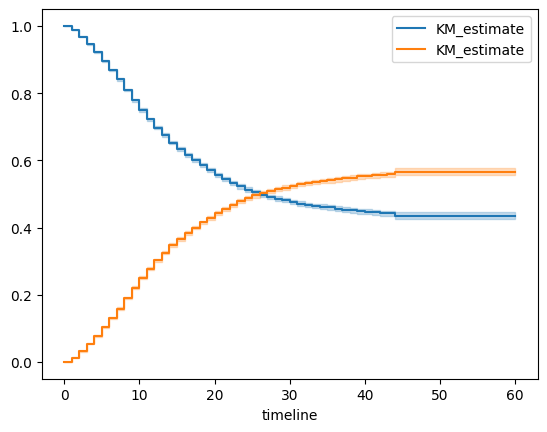

In [83]:
kmf = KaplanMeierFitter()
kmf.fit(durations=lifetest['time2'], event_observed=lifetest['default_time'])
#print(kmf.survival_function_)
kmf.plot_survival_function()
kmf.plot_cumulative_density()

<Axes: >

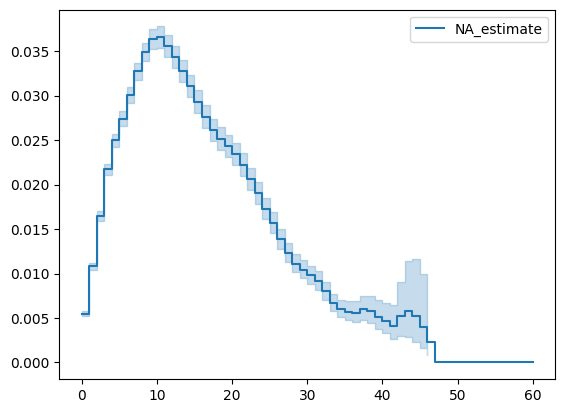

In [84]:
naf = NelsonAalenFitter()
naf.fit(durations=lifetest['time2'], event_observed=lifetest['default_time'])
#naf.plot_cumulative_hazard()
naf.plot_hazard(bandwidth=3)

<Axes: xlabel='timeline'>

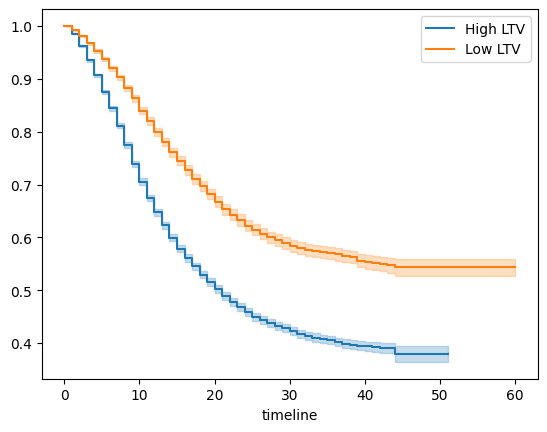

In [85]:
ax = plt.subplot(111)
high_ltv = (lifetest['LTV_orig_time'] >= 80)
kmf.fit(lifetest['time2'][high_ltv], event_observed=lifetest['default_time'][high_ltv], label='High LTV')
kmf.plot_survival_function(ax=ax)
kmf.fit(lifetest['time2'][~high_ltv], event_observed=lifetest['default_time'][~high_ltv], label='Low LTV')
kmf.plot_survival_function(ax=ax)

Here we replicate the Exhibit 7.5 from the book, that shows descriptive statistics for discrete time intervals including the number for failed observations, censored observations and effective sample size (number of observations at the beginning of the time interval less 50 percent of the number of censored observations). We assume that censoring occurs uniformly across the time interval.

- Conditional Probability of Failure: The number of default events divided by the effective sample size for a specific interval.
- Survival Rate: Calculated as 1 minus the current interval's failure probability, multiplied by the previous interval's survival rate.
- Probability Density Function (PDF): The survival rate multiplied by the failure probability, relative to the length of the time interval.
- Hazard Rate: Estimated as the default rate over the midpoint of the survival rate relative to the time interval length.

In [86]:
bins = [0, 10, 20, 30, 40, 50, 200]
labels = ['0-10', '10-20', '20-30', '30-40', '40-50', '50+']
mortgage_plot = lifetest.copy()
mortgage_plot['interval'] = pd.cut(mortgage_plot['time2'], bins=bins, labels=labels, right=False)
table = mortgage_plot.groupby('interval', observed=False).agg(
    no_failed=('default_time', 'sum'),
    no_censored=('default_time', lambda x: (x == 0).sum())
).reset_index()
table['interval'] = table['interval'].astype(str)
total_n = len(lifetest)
table['at_risk'] = total_n - (table['no_failed'] + table['no_censored']).cumsum().shift(1, fill_value=0)
table['E_S_Size'] = table['at_risk'] - (table['no_censored'] / 2)
table['CP_Failure'] = table['no_failed'] / table['E_S_Size']
table['Survival'] = (1 - table['CP_Failure']).cumprod().shift(1, fill_value=1.0)
table['Cumulative_Failure'] = 1 - table['Survival']
eps = 1e-10
variance_term = table['no_failed'] / (table['E_S_Size'] * (table['E_S_Size'] - table['no_failed'] + eps))
sum_var = variance_term.cumsum().shift(1, fill_value=0)
table['SE_Survival'] = table['Survival'] * np.sqrt(sum_var)
table['SE_Cumulative_Failure'] = table['SE_Survival']
h = 10  # Interval width
table['PDF'] = (table['Survival'] * table['CP_Failure']) / h
table['SE_PDF'] = table['PDF'] * np.sqrt(sum_var + ((table['E_S_Size'] - table['no_failed']) / (table['E_S_Size'] * table['no_failed'] + eps)))
q = table['CP_Failure']
table['Hazard'] = (2 * q) / (h * (2 - q + eps))
table['SE_Hazard'] = table['Hazard'] * np.sqrt((1 - (table['Hazard'] * h / 2)**2) / (table['E_S_Size'] * q + eps))
numeric_cols = table.select_dtypes(include=[np.number]).columns
table[numeric_cols] = table[numeric_cols].replace([np.inf, -np.inf], 0).fillna(0)

table

,interval,no_failed,no_censored,at_risk,E_S_Size,CP_Failure,Survival,Cumulative_Failure,SE_Survival,SE_Cumulative_Failure,PDF,SE_PDF,Hazard,SE_Hazard
0,0-10,8243,21300,50000,39350.0,0.209479,1.000000,0.000000,0.000000,0.000000,0.020948,0.000205,0.023399,0.000256
1,10-20,4880,4139,20457,18387.5,0.265398,0.790521,0.209479,0.002051,0.002051,0.020980,0.000263,0.030600,0.000433
2,20-30,1662,2083,11438,10396.5,0.159861,0.580719,0.419281,0.002983,0.002983,0.009283,0.000214,0.017375,0.000425
3,30-40,353,6031,7693,4677.5,0.075468,0.487884,0.512116,0.003261,0.003261,0.003682,0.000190,0.007843,0.000417
4,40-50,16,1286,1309,666.0,0.024024,0.451065,0.548935,0.003556,0.003556,0.001084,0.000268,0.002432,0.000608
5,50+,0,7,7,3.5,0.000000,0.440228,0.559772,0.004382,0.004382,0.000000,0.000000,0.000000,0.000000


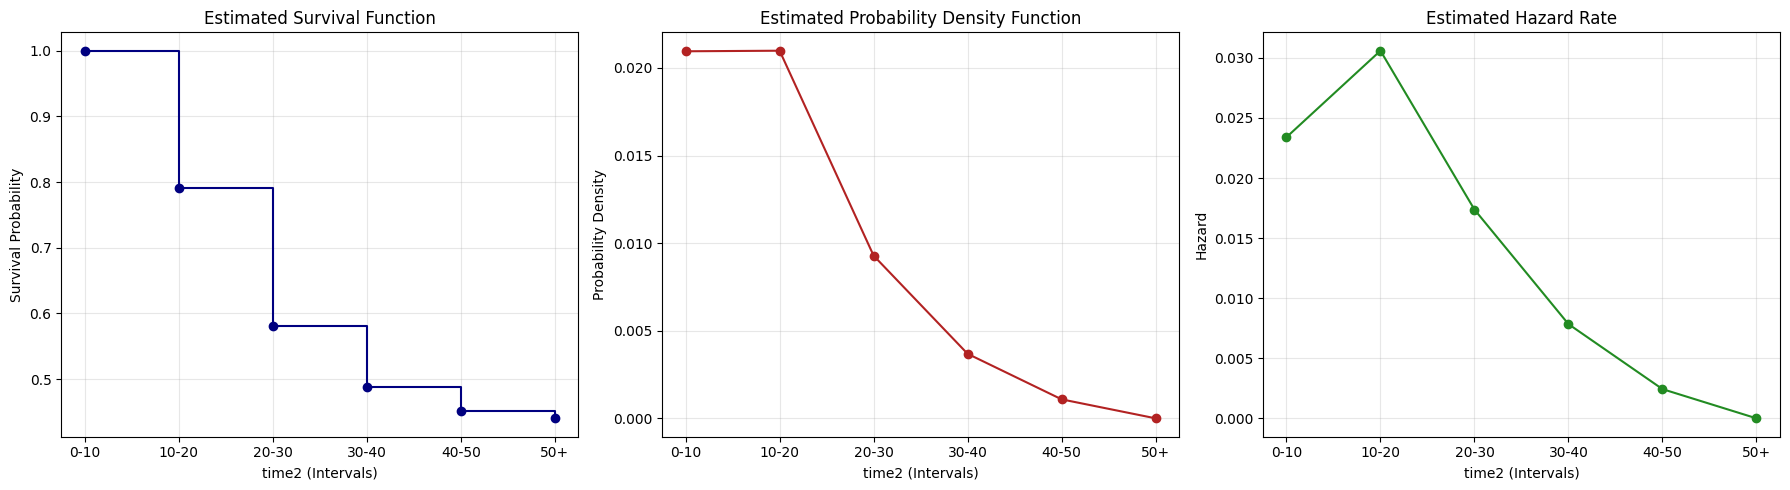

In [87]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].step(table['interval'], table['Survival'], where='post', marker='o', color='navy')
axes[0].set_title('Estimated Survival Function')
axes[0].set_ylabel('Survival Probability')
axes[0].set_xlabel('time2 (Intervals)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(table['interval'], table['PDF'], marker='o', linestyle='-', color='firebrick')
axes[1].set_title('Estimated Probability Density Function')
axes[1].set_ylabel('Probability Density')
axes[1].set_xlabel('time2 (Intervals)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(table['interval'], table['Hazard'], marker='o', linestyle='-', color='forestgreen')
axes[2].set_title('Estimated Hazard Rate')
axes[2].set_ylabel('Hazard')
axes[2].set_xlabel('time2 (Intervals)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Life tables are nonparametric and as such do not condition on coltrol information such as borrower, collateral, loan or economic variables. Despite these limitaitons, there is a simple way to inclusde observable information by means of stratification. To demonstrate this points, let's follow the book example and statify the result into five groups of equal size.

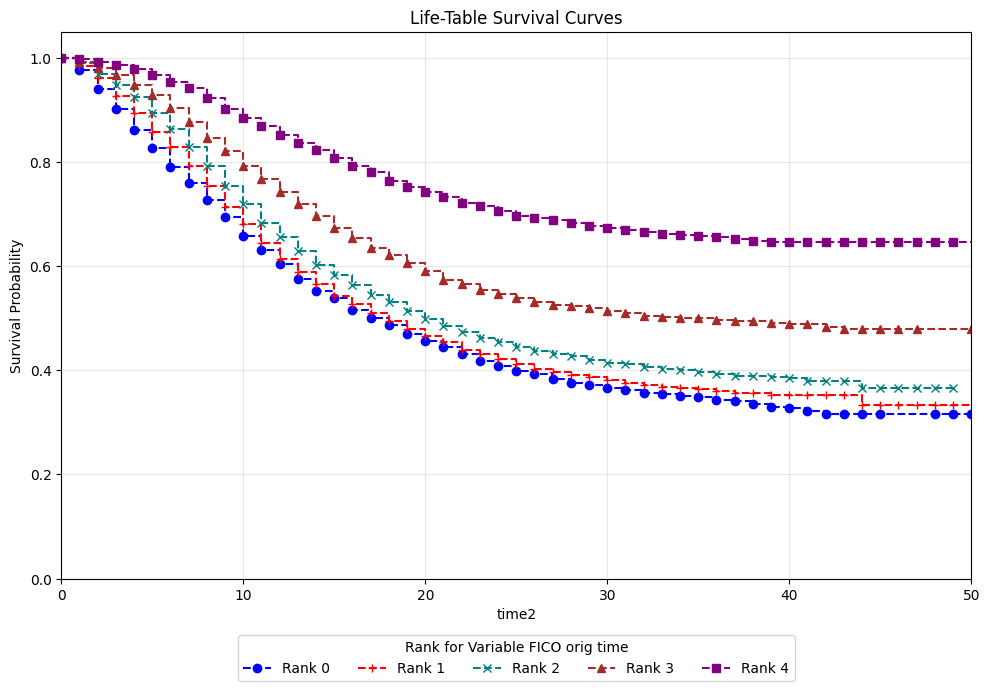

In [88]:
lifetest['FICO_rank'] = pd.qcut(lifetest['FICO_orig_time'], q=5, labels=False)
fig, ax = plt.subplots(figsize=(10, 7))
kmf = KaplanMeierFitter()
styles = [('o', 'blue'), ('+', 'red'), ('x', 'teal'), ('^', 'brown'), ('s', 'purple')]
for rank in range(5):
    subset = lifetest[lifetest['FICO_rank'] == rank]
    kmf.fit(
        durations=subset['time2'], 
        event_observed=subset['default_time'], 
        label=f'Rank {rank}'
    )
    marker, color = styles[rank]
    kmf.plot_survival_function(
        ax=ax, 
        ci_show=False, 
        marker=marker, 
        color=color, 
        linestyle='--'
    )
ax.set_title('Life-Table Survival Curves')
ax.set_xlabel('time2')
ax.set_ylabel('Survival Probability')
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 50)
ax.legend(title='Rank for Variable FICO orig time', loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

It is clear that the FICO score and survival probability are positively correlated. A low FICO score (like rank 0) has a greater default risk, which results in a low survival probability; a high score (like rank 4) has less risk, and a high survival probability.

### Test of Equality over Groups
The Kaplan-Meier estimator does not account for the presence of covariates. It is a very useful tool for exploring and describing your survival data. However, other techniques are needed for building predictive survival analysis. A first extension of Kaplan-Meier analysis is to statistically test the equivalence of survival curves of different samples.

In [89]:
results = []
lr_results = multivariate_logrank_test(lifetest['time2'], lifetest['default_time'], lifetest['FICO_rank'])
results.append({
    'Test': 'Log-Rank',
    'Chi-Square': lr_results.test_statistic,
    'DF': lr_results.degrees_of_freedom,
    'Pr > Chi-Square': lr_results.p_value
})

df_cox = pd.get_dummies(lifetest[['time2', 'default_time', 'FICO_rank']], columns=['FICO_rank'], drop_first=True)
cph = CoxPHFitter()
cph.fit(df_cox, duration_col='time2', event_col='default_time')
lrt = cph.log_likelihood_ratio_test()
results.append({
    'Test': '-2Log(LR)',
    'DF': lrt.degrees_freedom,
    'Pr > Chi-Square': lrt.p_value
})

report = pd.DataFrame(results)
report['Pr > Chi-Square'] = report['Pr > Chi-Square'].apply(lambda x: '<.0001' if x < 0.0001 else f"{x:.4f}")
report

,Test,Chi-Square,DF,Pr > Chi-Square
0,Log-Rank,490.237389,1,<.0001
1,-2Log(LR),NaN,4,<.0001
